In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [5]:
ALL_Data =  pd.read_csv("All_features.csv",index_col="Date",parse_dates=["Date"]).dropna()


In [11]:
print("Shape         :", ALL_Data.shape)
print("\nDate Range    :", ALL_Data.index.min(), "→", ALL_Data.index.max())
print("\nNull Count:\n", ALL_Data.isnull().sum())
print("\nDuplicates    :", ALL_Data.index.duplicated().sum())

Shape         : (2342, 17)

Date Range    : 2015-01-05 00:00:00 → 2025-12-30 00:00:00

Null Count:
 HDFCBANK     0
NIFTY50      0
BANKNIFTY    0
SENSEX       0
INDIA_VIX    0
USDINR       0
SP500        0
NASDAQ100    0
DOWJONES     0
NIKKEI225    0
HANGSENG     0
GOLD         0
BRENT_OIL    0
ICICIBANK    0
SBIN         0
AXISBANK     0
KOTAKBANK    0
dtype: int64

Duplicates    : 0


In [15]:
print("=" * 45)
print("STATIONARITY CHECK — RAW PRICES")
print("=" * 45)

for col in ALL_Data.columns:
    result = adfuller(ALL_Data[col].dropna())
    status = "✅ STATIONARY" if result[1] < 0.05 else "❌ NOT STATIONARY"
    print(f"{col:<15} p-value: {result[1]:.4f}  →  {status}")

STATIONARITY CHECK — RAW PRICES
HDFCBANK        p-value: 0.8291  →  ❌ NOT STATIONARY
NIFTY50         p-value: 0.1846  →  ❌ NOT STATIONARY
BANKNIFTY       p-value: 1.0000  →  ❌ NOT STATIONARY
SENSEX          p-value: 0.8286  →  ❌ NOT STATIONARY
INDIA_VIX       p-value: 0.9845  →  ❌ NOT STATIONARY
USDINR          p-value: 0.9559  →  ❌ NOT STATIONARY
SP500           p-value: 0.6854  →  ❌ NOT STATIONARY
NASDAQ100       p-value: 0.9937  →  ❌ NOT STATIONARY
DOWJONES        p-value: 0.9793  →  ❌ NOT STATIONARY
NIKKEI225       p-value: 0.9831  →  ❌ NOT STATIONARY
HANGSENG        p-value: 0.9947  →  ❌ NOT STATIONARY
GOLD            p-value: 0.2712  →  ❌ NOT STATIONARY
BRENT_OIL       p-value: 0.0000  →  ✅ STATIONARY
ICICIBANK       p-value: 0.9943  →  ❌ NOT STATIONARY
SBIN            p-value: 0.9963  →  ❌ NOT STATIONARY
AXISBANK        p-value: 0.9694  →  ❌ NOT STATIONARY
KOTAKBANK       p-value: 0.9820  →  ❌ NOT STATIONARY


In [19]:
# Log return = log(today / yesterday)
log_returns = np.log(ALL_Data / ALL_Data.shift(1)).dropna()

print("Log Returns Shape:", log_returns.shape)
log_returns.head()

Log Returns Shape: (2341, 17)


,HDFCBANK,NIFTY50,BANKNIFTY,SENSEX,INDIA_VIX,USDINR,SP500,NASDAQ100,DOWJONES,NIKKEI225,HANGSENG,GOLD,BRENT_OIL,ICICIBANK,SBIN,AXISBANK,KOTAKBANK
Date,,,,,,,,,,,,,,,,,
2015-01-06,-0.036400,-0.038581,0.012711,-0.015689,-0.043344,0.000948,-0.011995,-0.041955,-0.031185,-0.007456,-0.008933,-0.009995,0.207904,-0.030652,-0.012121,-0.031334,-0.030422
2015-01-07,-0.000802,0.000978,-0.007161,0.002914,-0.027411,0.003625,0.015974,0.000833,-0.002918,0.012180,0.011563,0.008305,0.040500,0.000127,0.011890,-0.006887,-0.003112
2015-01-08,0.006596,-0.003722,-0.001819,0.020788,0.026836,-0.004652,0.052957,0.015538,0.013506,0.018221,0.017730,0.006493,-0.096579,0.016550,0.019178,0.021465,0.016221
2015-01-09,-0.014044,-0.016820,0.006270,0.011131,-0.016249,-0.009608,0.015028,-0.005427,0.006712,-0.009567,-0.008439,0.003536,-0.031455,0.001783,-0.006452,-0.003436,0.006042
2015-01-13,0.019111,-0.072835,0.014937,-0.012687,-0.002783,-0.009620,0.023241,0.006247,-0.001190,-0.006998,-0.010709,0.012300,0.032062,-0.006418,-0.011237,0.003746,0.001797


In [21]:
print("=" * 45)
print("STATIONARITY CHECK — LOG RETURNS")
print("=" * 45)

all_stationary = True
for col in log_returns.columns:
    result = adfuller(log_returns[col].dropna())
    status = "✅ STATIONARY" if result[1] < 0.05 else "❌ STILL NOT STATIONARY"
    if result[1] >= 0.05:
        all_stationary = False
    print(f"{col:<15} p-value: {result[1]:.4f}  →  {status}")

print("\n" + ("✅ ALL assets stationary after log returns!" if all_stationary else "⚠️ Some assets still not stationary — check above"))

STATIONARITY CHECK — LOG RETURNS
HDFCBANK        p-value: 0.0000  →  ✅ STATIONARY
NIFTY50         p-value: 0.0000  →  ✅ STATIONARY
BANKNIFTY       p-value: 0.0000  →  ✅ STATIONARY
SENSEX          p-value: 0.0000  →  ✅ STATIONARY
INDIA_VIX       p-value: 0.0000  →  ✅ STATIONARY
USDINR          p-value: 0.0000  →  ✅ STATIONARY
SP500           p-value: 0.0000  →  ✅ STATIONARY
NASDAQ100       p-value: 0.0000  →  ✅ STATIONARY
DOWJONES        p-value: 0.0000  →  ✅ STATIONARY
NIKKEI225       p-value: 0.0000  →  ✅ STATIONARY
HANGSENG        p-value: 0.0000  →  ✅ STATIONARY
GOLD            p-value: 0.0000  →  ✅ STATIONARY
BRENT_OIL       p-value: 0.0000  →  ✅ STATIONARY
ICICIBANK       p-value: 0.0000  →  ✅ STATIONARY
SBIN            p-value: 0.0000  →  ✅ STATIONARY
AXISBANK        p-value: 0.0000  →  ✅ STATIONARY
KOTAKBANK       p-value: 0.0000  →  ✅ STATIONARY

✅ ALL assets stationary after log returns!


In [23]:
# Work on a copy
features_df = log_returns.copy()

# --- HDFC Lag Features ---
features_df['HDFC_lag1']  = log_returns['HDFCBANK'].shift(1)   # yesterday's return
features_df['HDFC_lag5']  = log_returns['HDFCBANK'].shift(5)   # 1 week ago
features_df['HDFC_lag10'] = log_returns['HDFCBANK'].shift(10)  # 2 weeks ago

# --- SMA Features (on lagged HDFC returns) ---
features_df['HDFC_SMA10']  = log_returns['HDFCBANK'].shift(1).rolling(10).mean()
features_df['HDFC_SMA50']  = log_returns['HDFCBANK'].shift(1).rolling(50).mean()
features_df['HDFC_SMA200'] = log_returns['HDFCBANK'].shift(1).rolling(200).mean()

# --- EMA Features ---
features_df['HDFC_EMA10']  = log_returns['HDFCBANK'].shift(1).ewm(span=10).mean()
features_df['HDFC_EMA50']  = log_returns['HDFCBANK'].shift(1).ewm(span=50).mean()
features_df['HDFC_EMA200'] = log_returns['HDFCBANK'].shift(1).ewm(span=200).mean()

# --- Momentum (sum of last 10 log returns = total return over 10 days) ---
features_df['HDFC_momentum10'] = log_returns['HDFCBANK'].shift(1).rolling(10).sum()

print("✅ Features added. Shape:", features_df.shape)
features_df[['HDFC_lag1','HDFC_SMA10','HDFC_EMA10','HDFC_momentum10']].tail(5)

✅ Features added. Shape: (2341, 27)


,HDFC_lag1,HDFC_SMA10,HDFC_EMA10,HDFC_momentum10
Date,,,,
2025-12-22,0.000650,-0.004131,-0.003375,-0.041309
2025-12-23,0.002111,-0.003239,-0.002378,-0.032392
2025-12-24,-0.006672,-0.004071,-0.003159,-0.040711
2025-12-29,0.001061,-0.004176,-0.002391,-0.041764
2025-12-30,0.004637,-0.003250,-0.001113,-0.032502


In [25]:
# Target = direction of TOMORROW's HDFC return
# 1 = positive return (price goes UP)
# 0 = negative return (price goes DOWN or flat)

features_df['Target'] = (log_returns['HDFCBANK'].shift(-1) > 0).astype(int)

print("Target distribution:")
print(features_df['Target'].value_counts())
print(f"\nUp days   : {features_df['Target'].sum()} ({features_df['Target'].mean()*100:.1f}%)")
print(f"Down days : {(features_df['Target']==0).sum()} ({(1-features_df['Target'].mean())*100:.1f}%)")

Target distribution:
1    1212
0    1129
Name: Target, dtype: int64

Up days   : 1212 (51.8%)
Down days : 1129 (48.2%)


In [27]:
features_df.dropna(inplace=True)

print("✅ Final shape after dropping NaNs:", features_df.shape)
print("Features (X columns):", features_df.shape[1] - 1)
print("Date range:", features_df.index.min(), "→", features_df.index.max())

✅ Final shape after dropping NaNs: (2141, 28)
Features (X columns): 27
Date range: 2015-12-11 00:00:00 → 2025-12-30 00:00:00


In [29]:
# Drop HDFCBANK from X — it's the raw log return, not a feature
# We already have lag1/lag5/lag10 capturing HDFC's own history
X = features_df.drop(columns=['HDFCBANK', 'Target'])
Y = features_df['Target']

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("\nFeature columns:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2}. {col}")

X shape: (2141, 26)
Y shape: (2141,)

Feature columns:
   1. NIFTY50
   2. BANKNIFTY
   3. SENSEX
   4. INDIA_VIX
   5. USDINR
   6. SP500
   7. NASDAQ100
   8. DOWJONES
   9. NIKKEI225
  10. HANGSENG
  11. GOLD
  12. BRENT_OIL
  13. ICICIBANK
  14. SBIN
  15. AXISBANK
  16. KOTAKBANK
  17. HDFC_lag1
  18. HDFC_lag5
  19. HDFC_lag10
  20. HDFC_SMA10
  21. HDFC_SMA50
  22. HDFC_SMA200
  23. HDFC_EMA10
  24. HDFC_EMA50
  25. HDFC_EMA200
  26. HDFC_momentum10


In [31]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.20,
    shuffle=False      # ← CRITICAL: no random shuffle for time series!
)

print("Train size :", X_train.shape[0], "rows |", X_train.index.min(), "→", X_train.index.max())
print("Test size  :", X_test.shape[0],  "rows |", X_test.index.min(),  "→", X_test.index.max())
print("\nTrain target split:", Y_train.value_counts().to_dict())
print("Test  target split:", Y_test.value_counts().to_dict())

# Confirm NO date overlap between train and test
assert X_train.index.max() < X_test.index.min(), "❌ DATE OVERLAP DETECTED!"
print("\n✅ No date overlap between train and test")

Train size : 1712 rows | 2015-12-11 00:00:00 → 2023-12-19 00:00:00
Test size  : 429 rows | 2023-12-20 00:00:00 → 2025-12-30 00:00:00

Train target split: {1: 906, 0: 806}
Test  target split: {0: 217, 1: 212}

✅ No date overlap between train and test


In [33]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # ONLY transform on test

print("✅ Scaling done")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape :", X_test_scaled.shape)

✅ Scaling done
X_train_scaled shape: (1712, 26)
X_test_scaled shape : (429, 26)


In [37]:
# TimeSeriesSplit — respects time order during cross-validation
tscv = TimeSeriesSplit(n_splits=5)

# Parameter grid — 3 parameters, 5×4×4 = 80 combinations
param_grid = {
    'max_depth'        : [2, 3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10]
}

# Classifier with accuracy scoring
dt = DecisionTreeClassifier(random_state=42)

grid = GridSearchCV(
    estimator  = dt,
    param_grid = param_grid,
    cv         = tscv,
    scoring    = 'accuracy',
    n_jobs     = 1,           # use all CPU cores
    verbose    = 1
)

grid.fit(X_train_scaled, Y_train)

print("\n✅ GridSearchCV complete!")
print("Best Parameters :", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_ * 100, 2), "%")

Fitting 5 folds for each of 112 candidates, totalling 560 fits

✅ GridSearchCV complete!
Best Parameters : {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Accuracy: 54.46 %


In [39]:
best_model = grid.best_estimator_

# Confirm it's already fitted on X_train_scaled
train_preds = best_model.predict(X_train_scaled)
train_acc   = accuracy_score(Y_train, train_preds)

print("Best Model        :", best_model)
print("Train Accuracy    :", round(train_acc * 100, 2), "%")

Best Model        : DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
Train Accuracy    : 63.55 %


In [41]:
test_preds = best_model.predict(X_test_scaled)
test_acc   = accuracy_score(Y_test, test_preds)

print("=" * 40)
print("OVERFITTING CHECK")
print("=" * 40)
print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test  Accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%")

if (train_acc - test_acc) > 0.10:
    print("\n⚠️  Gap > 10% — model is OVERFITTING")
elif test_acc < 0.50:
    print("\n⚠️  Test accuracy below 50% — worse than random guess!")
else:
    print("\n✅ Model is generalising well")

OVERFITTING CHECK
Train Accuracy : 63.55%
Test  Accuracy : 50.58%
Gap            : 12.97%

⚠️  Gap > 10% — model is OVERFITTING


In [43]:
# Force tighter model to reduce overfitting
tuned_model = DecisionTreeClassifier(
    max_depth         = 3,    # shallower than grid's 5
    min_samples_split = 20,   # need more samples to make a split
    min_samples_leaf  = 15,   # each leaf needs at least 15 samples
    random_state      = 42
)

tuned_model.fit(X_train_scaled, Y_train)

train_preds2 = tuned_model.predict(X_train_scaled)
test_preds2  = tuned_model.predict(X_test_scaled)

train_acc2 = accuracy_score(Y_train, train_preds2)
test_acc2  = accuracy_score(Y_test,  test_preds2)

print("=" * 40)
print("TIGHTER MODEL — OVERFITTING CHECK")
print("=" * 40)
print(f"Train Accuracy : {train_acc2*100:.2f}%")
print(f"Test  Accuracy : {test_acc2*100:.2f}%")
print(f"Gap            : {(train_acc2 - test_acc2)*100:.2f}%")

if (train_acc2 - test_acc2) < 0.05:
    print("\n✅ Excellent — gap under 5%, model generalising well!")
elif (train_acc2 - test_acc2) < 0.10:
    print("\n✅ Good — gap under 10%, acceptable generalisation")
else:
    print("\n⚠️  Still overfitting — but we'll proceed to evaluation")

TIGHTER MODEL — OVERFITTING CHECK
Train Accuracy : 57.30%
Test  Accuracy : 49.65%
Gap            : 7.65%

✅ Good — gap under 10%, acceptable generalisation


In [45]:
# Use best_model (depth=5, 50.58% test acc) — slightly better than tuned
final_preds = best_model.predict(X_test_scaled)

print("=" * 50)
print("FULL EVALUATION ON TEST SET")
print("=" * 50)
print(f"Test Accuracy : {accuracy_score(Y_test, final_preds)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(Y_test, final_preds, target_names=['Down (0)', 'Up (1)']))

print("Confusion Matrix:")
cm = confusion_matrix(Y_test, final_preds)
print(f"                Predicted Down  Predicted Up")
print(f"Actual Down  :  {cm[0][0]:>12}  {cm[0][1]:>12}")
print(f"Actual Up    :  {cm[1][0]:>12}  {cm[1][1]:>12}")

FULL EVALUATION ON TEST SET
Test Accuracy : 50.58%

Classification Report:
              precision    recall  f1-score   support

    Down (0)       0.52      0.39      0.44       217
      Up (1)       0.50      0.63      0.56       212

    accuracy                           0.51       429
   macro avg       0.51      0.51      0.50       429
weighted avg       0.51      0.51      0.50       429

Confusion Matrix:
                Predicted Down  Predicted Up
Actual Down  :            84           133
Actual Up    :            79           133


In [47]:
# Naive benchmark = always predict UP (since market drifts up slightly)
naive_preds = np.ones(len(Y_test), dtype=int)
naive_acc   = accuracy_score(Y_test, naive_preds)

print("=" * 50)
print("BENCHMARK COMPARISON")
print("=" * 50)
print(f"Our Model Accuracy  : {accuracy_score(Y_test, final_preds)*100:.2f}%")
print(f"Naive 'Always Up'   : {naive_acc*100:.2f}%")
print(f"Random Guess        : 50.00%")

if accuracy_score(Y_test, final_preds) > naive_acc:
    print("\n✅ Our model BEATS the naive benchmark!")
else:
    print("\n⚠️  Naive benchmark wins — but backtesting may still show value")

BENCHMARK COMPARISON
Our Model Accuracy  : 50.58%
Naive 'Always Up'   : 49.42%
Random Guess        : 50.00%

✅ Our model BEATS the naive benchmark!


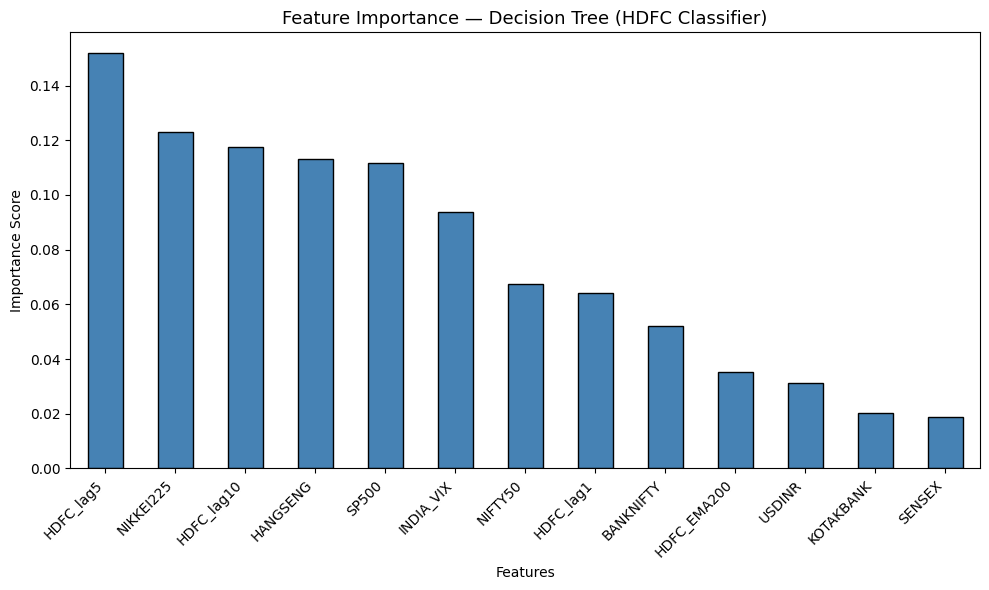


Top 5 Most Important Features:
HDFC_lag5     0.151879
NIKKEI225     0.123197
HDFC_lag10    0.117693
HANGSENG      0.113271
SP500         0.111601


In [49]:
# Get feature importances
feat_imp = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Keep only features the tree actually used
used_features = feat_imp[feat_imp > 0]

plt.figure(figsize=(10, 6))
used_features.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importance — Decision Tree (HDFC Classifier)', fontsize=13)
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nTop 5 Most Important Features:")
print(feat_imp.head(5).to_string())

In [51]:
# Get HDFC actual log returns on the test period
test_actual_returns = log_returns.loc[X_test.index, 'HDFCBANK']

# Strategy: Buy (hold) when model predicts UP (1), stay out when DOWN (0)
strategy_returns = test_actual_returns * final_preds

# Buy-and-hold: just hold HDFC entire test period
buyhold_returns = test_actual_returns

# Cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_buyhold  = (1 + buyhold_returns).cumprod()

print("=" * 50)
print("BACKTESTING RESULTS")
print("=" * 50)
print(f"Strategy Final Return  : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return      : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Strategy Outperforms   : {cum_strategy.iloc[-1] > cum_buyhold.iloc[-1]}")

BACKTESTING RESULTS
Strategy Final Return  : 4.69%
Buy & Hold Return      : 5.72%
Strategy Outperforms   : False


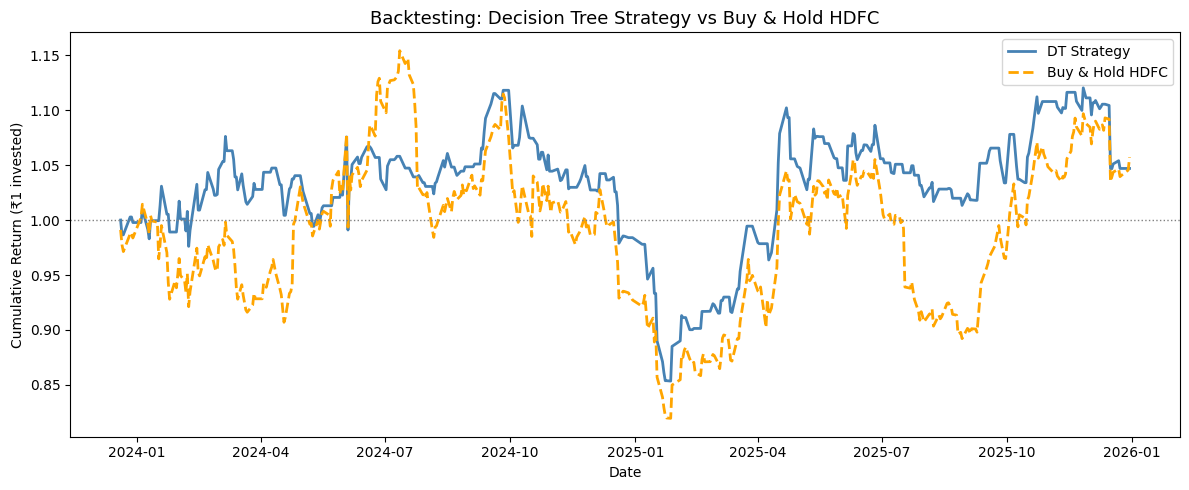

In [53]:
plt.figure(figsize=(12, 5))
plt.plot(cum_strategy.index, cum_strategy.values, 
         label='DT Strategy', color='steelblue', linewidth=2)
plt.plot(cum_buyhold.index,  cum_buyhold.values,  
         label='Buy & Hold HDFC', color='orange', linewidth=2, linestyle='--')
plt.axhline(y=1, color='grey', linestyle=':', linewidth=1)
plt.title('Backtesting: Decision Tree Strategy vs Buy & Hold HDFC', fontsize=13)
plt.xlabel('Date')
plt.ylabel('Cumulative Return (₹1 invested)')
plt.legend()
plt.tight_layout()
plt.show()

In [55]:
total_days    = len(final_preds)
days_in_mkt   = final_preds.sum()
days_out_mkt  = total_days - days_in_mkt
win_rate      = accuracy_score(Y_test, final_preds)

print("=" * 50)
print("        FINAL MODEL SUMMARY CARD")
print("=" * 50)
print(f"Test Period           : {X_test.index.min().date()} → {X_test.index.max().date()}")
print(f"Total Trading Days    : {total_days}")
print(f"Days In Market        : {days_in_mkt}  ({days_in_mkt/total_days*100:.1f}%)")
print(f"Days Out of Market    : {days_out_mkt} ({days_out_mkt/total_days*100:.1f}%)")
print(f"Directional Accuracy  : {win_rate*100:.2f}%")
print(f"Strategy Return       : {(cum_strategy.iloc[-1]-1)*100:.2f}%")
print(f"Buy & Hold Return     : {(cum_buyhold.iloc[-1]-1)*100:.2f}%")
print(f"Alpha Generated       : {(cum_strategy.iloc[-1]-cum_buyhold.iloc[-1])*100:.2f}%")

        FINAL MODEL SUMMARY CARD
Test Period           : 2023-12-20 → 2025-12-30
Total Trading Days    : 429
Days In Market        : 266  (62.0%)
Days Out of Market    : 163 (38.0%)
Directional Accuracy  : 50.58%
Strategy Return       : 4.69%
Buy & Hold Return     : 5.72%
Alpha Generated       : -1.03%


# optimization 

In [62]:
# RSI = Relative Strength Index — measures overbought/oversold momentum
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0)
    loss  = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs  = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

hdfc_price = ALL_Data['HDFCBANK']   # raw price, not log returns

features_df['HDFC_RSI14']  = compute_rsi(hdfc_price, 14)
features_df['HDFC_RSI5']   = compute_rsi(hdfc_price, 5)   # short-term RSI

print("✅ RSI features added")
print(features_df[['HDFC_RSI14', 'HDFC_RSI5']].tail(5))

✅ RSI features added
            HDFC_RSI14  HDFC_RSI5
Date                             
2025-12-22   43.911253  34.082040
2025-12-23   41.386260  27.962879
2025-12-24   41.956127  30.438002
2025-12-29   44.503745  41.461159
2025-12-30   50.276475  60.620218


In [64]:
# Bollinger Band Width — measures volatility squeeze/expansion
rolling_mean = hdfc_price.rolling(20).mean()
rolling_std  = hdfc_price.rolling(20).std()

upper_band = rolling_mean + (2 * rolling_std)
lower_band = rolling_mean - (2 * rolling_std)

# Band width = how wide the bands are (high = volatile, low = quiet/squeeze)
features_df['HDFC_BB_width'] = (upper_band - lower_band) / rolling_mean

# %B = where price sits within the bands (above 1 = overbought, below 0 = oversold)
features_df['HDFC_BB_pct']   = (hdfc_price - lower_band) / (upper_band - lower_band)

print("✅ Bollinger Band features added")
print(features_df[['HDFC_BB_width', 'HDFC_BB_pct']].tail(5))

✅ Bollinger Band features added
            HDFC_BB_width  HDFC_BB_pct
Date                                  
2025-12-22       0.072890     0.161094
2025-12-23       0.077590     0.123175
2025-12-24       0.081601     0.173229
2025-12-29       0.080775     0.253922
2025-12-30       0.079376     0.406664


In [69]:
# Drop NaN rows created by new features (RSI needs 14 days, BB needs 20 days)
features_df.dropna(inplace=True)

# Rebuild X and Y with new features
X = features_df.drop(columns=['HDFCBANK', 'Target'])
Y = features_df['Target']

print(f"✅ New feature count : {X.shape[1]} features (was 26)")
print(f"✅ Total rows        : {X.shape[0]}")
print(f"\nNew feature columns added:")
new_cols = ['HDFC_RSI14', 'HDFC_RSI5', 'HDFC_BB_width', 'HDFC_BB_pct', 'HDFC_vol_ratio']
for col in new_cols:
    print(f"   → {col}")

✅ New feature count : 30 features (was 26)
✅ Total rows        : 2141

New feature columns added:
   → HDFC_RSI14
   → HDFC_RSI5
   → HDFC_BB_width
   → HDFC_BB_pct
   → HDFC_vol_ratio


In [71]:
# Redo split and scaling with new features
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.20, shuffle=False
)

scaler       = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"✅ X_train_scaled : {X_train_scaled.shape}")
print(f"✅ X_test_scaled  : {X_test_scaled.shape}")
assert X_train.index.max() < X_test.index.min(), "❌ DATE OVERLAP!"
print("✅ No date overlap confirmed")

✅ X_train_scaled : (1712, 30)
✅ X_test_scaled  : (429, 30)
✅ No date overlap confirmed


In [73]:
tscv = TimeSeriesSplit(n_splits=5)

param_grid = {
    'max_depth'        : [2, 3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10]
}

dt   = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, param_grid, cv=tscv,
                    scoring='accuracy', n_jobs=1, verbose=1)
grid.fit(X_train_scaled, Y_train)

best_model = grid.best_estimator_

test_preds_new = best_model.predict(X_test_scaled)
new_acc        = accuracy_score(Y_test, test_preds_new)

print("\n✅ GridSearchCV complete!")
print("Best Parameters :", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_ * 100, 2), "%")
print(f"\nTest Accuracy (30 features) : {new_acc*100:.2f}%")
print(f"Test Accuracy (26 features) : 50.58%  ← old score")
print(f"Improvement                 : {(new_acc - 0.5058)*100:+.2f}%")

Fitting 5 folds for each of 112 candidates, totalling 560 fits

✅ GridSearchCV complete!
Best Parameters : {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 2}
Best CV Accuracy: 54.6 %

Test Accuracy (30 features) : 50.12%
Test Accuracy (26 features) : 50.58%  ← old score
Improvement                 : -0.46%


In [75]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators  = 200,       # 200 trees voting together
    max_depth     = 10,        # each tree can go deeper
    min_samples_leaf = 5,
    max_features  = 'sqrt',    # each tree sees sqrt(30) ≈ 5 random features
    random_state  = 42,
    n_jobs        = 1          # keep 1 to avoid Windows crash
)

rf.fit(X_train_scaled, Y_train)

rf_train_preds = rf.predict(X_train_scaled)
rf_test_preds  = rf.predict(X_test_scaled)

rf_train_acc = accuracy_score(Y_train, rf_train_preds)
rf_test_acc  = accuracy_score(Y_test,  rf_test_preds)

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print(f"Train Accuracy  : {rf_train_acc*100:.2f}%")
print(f"Test  Accuracy  : {rf_test_acc*100:.2f}%")
print(f"Gap             : {(rf_train_acc - rf_test_acc)*100:.2f}%")
print(f"\nDecision Tree   : 50.58%  ← old")
print(f"Random Forest   : {rf_test_acc*100:.2f}%  ← new")
print(f"Improvement     : {(rf_test_acc - 0.5058)*100:+.2f}%")

RANDOM FOREST RESULTS
Train Accuracy  : 96.03%
Test  Accuracy  : 50.82%
Gap             : 45.21%

Decision Tree   : 50.58%  ← old
Random Forest   : 50.82%  ← new
Improvement     : +0.24%


In [77]:
rf_param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [5, 10, 15, None],
    'min_samples_leaf': [2, 5, 10]
}

rf_base  = RandomForestClassifier(random_state=42, n_jobs=1)
rf_grid  = GridSearchCV(rf_base, rf_param_grid,
                        cv=tscv, scoring='accuracy',
                        n_jobs=1, verbose=1)

rf_grid.fit(X_train_scaled, Y_train)

best_rf = rf_grid.best_estimator_
best_rf_preds = best_rf.predict(X_test_scaled)
best_rf_acc   = accuracy_score(Y_test, best_rf_preds)

print("\n✅ RF GridSearchCV complete!")
print("Best Params  :", rf_grid.best_params_)
print("Best CV Acc  :", round(rf_grid.best_score_*100, 2), "%")
print(f"Test Accuracy: {best_rf_acc*100:.2f}%")
print(f"DT Baseline  : 50.58%")
print(f"Improvement  : {(best_rf_acc - 0.5058)*100:+.2f}%")

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ RF GridSearchCV complete!
Best Params  : {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
Best CV Acc  : 56.84 %
Test Accuracy: 50.12%
DT Baseline  : 50.58%
Improvement  : -0.46%


In [79]:
# Fix: reduce max_features + increase min_samples_leaf + cap depth harder
rf_fixed = RandomForestClassifier(
    n_estimators     = 200,
    max_depth        = 4,        # shallower trees
    min_samples_leaf = 20,       # much larger — each leaf needs 20 samples
    max_features     = 0.3,      # each tree only sees 30% of features (≈9 features)
    random_state     = 42,
    n_jobs           = 1
)

rf_fixed.fit(X_train_scaled, Y_train)

rf_train = accuracy_score(Y_train, rf_fixed.predict(X_train_scaled))
rf_test  = accuracy_score(Y_test,  rf_fixed.predict(X_test_scaled))

print("=" * 45)
print("FIXED RANDOM FOREST — OVERFIT CHECK")
print("=" * 45)
print(f"Train Accuracy : {rf_train*100:.2f}%")
print(f"Test  Accuracy : {rf_test*100:.2f}%")
print(f"Gap            : {(rf_train - rf_test)*100:.2f}%")
print(f"\nDT Baseline    : 50.58%")
print(f"RF Fixed       : {rf_test*100:.2f}%")
print(f"Improvement    : {(rf_test - 0.5058)*100:+.2f}%")

if (rf_train - rf_test) < 0.10:
    print("\n✅ Overfitting controlled!")
elif (rf_train - rf_test) < 0.20:
    print("\n⚠️  Mild overfit — acceptable, proceed")
else:
    print("\n🔴 Still overfitting — tell me the gap")

FIXED RANDOM FOREST — OVERFIT CHECK
Train Accuracy : 68.57%
Test  Accuracy : 47.79%
Gap            : 20.79%

DT Baseline    : 50.58%
RF Fixed       : 47.79%
Improvement    : -2.79%

🔴 Still overfitting — tell me the gap


In [81]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(
    learning_rate=0.1,
    n_estimators=200,
    max_depth=3,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_scaled, Y_train)
print("Train acc:", accuracy_score(Y_train, gb.predict(X_train_scaled)))
print("Test  acc:", accuracy_score(Y_test, gb.predict(X_test_scaled)))

Train acc: 0.951518691588785
Test  acc: 0.5058275058275058


In [87]:
import xgboost as xgb
xgb_clf = xgb.XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.6,
    random_state=42,
    n_jobs=1
)
xgb_clf.fit(X_train_scaled, Y_train)
print("XGB Test acc:", accuracy_score(Y_test, xgb_clf.predict(X_test_scaled)))

XGB Test acc: 0.5011655011655012


In [91]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100,200],
    'max_depth': [3,5],
    'learning_rate': [0.01, 0.05, 0.1]
}
# for sklearn's GradientBoostingClassifier:
grid = GridSearchCV(GradientBoostingClassifier(random_state=42), param_grid,
                    cv=tscv, scoring='accuracy', n_jobs=1, verbose=1)
grid.fit(X_train_scaled, Y_train)
print("Best params:", grid.best_params_)
print("CV acc   :", grid.best_score_)
print("Test acc :", accuracy_score(Y_test, grid.best_estimator_.predict(X_test_scaled)))

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
CV acc   : 0.5536842105263158
Test acc : 0.4801864801864802


In [95]:
from sklearn.base import clone
import numpy as np

train_window = 252*2   # approx 2 years of trading days (adjust to your data frequency)
test_window  = 63      # ~3 months
start = 0
accs = []

dates = X.index
N = len(X)
i = 0
while True:
    train_start = start + i*test_window
    train_end   = train_start + train_window
    test_end    = train_end + test_window
    if test_end > N:
        break
    X_tr = X.iloc[train_start:train_end]
    y_tr = Y.iloc[train_start:train_end]
    X_te = X.iloc[train_end:test_end]
    y_te = Y.iloc[train_end:test_end]

    # scale using train scaler only
    scaler_wf = StandardScaler().fit(X_tr)
    X_tr_s = scaler_wf.transform(X_tr)
    X_te_s = scaler_wf.transform(X_te)

    model = clone(grid.best_estimator_ if 'grid' in globals() else gb)  # use tuned booster if available
    model.fit(X_tr_s, y_tr)
    acc = accuracy_score(y_te, model.predict(X_te_s))
    accs.append(acc)
    i += 1

print("Walk-forward windows:", len(accs))
print("Mean WF accuracy:", np.mean(accs), "Std:", np.std(accs))

Walk-forward windows: 25
Mean WF accuracy: 0.5168253968253969 Std: 0.08327874251209953


In [97]:
tc = 0.0005   # e.g., 0.05% per trade
slippage = 0.0002

probs = grid.best_estimator_.predict_proba(X_test_scaled)[:,1] if 'grid' in globals() else gb.predict_proba(X_test_scaled)[:,1]
preds = (probs > 0.5).astype(int)

# Use test_actual_returns series (log returns or simple returns consistent with earlier code)
test_returns = log_returns.loc[X_test.index, 'HDFCBANK']  # ensure this matches earlier variable

# Strategy returns: when in market, take the next day's return, but subtract costs on entry and exit
strategy_returns = []
position = 0
for i in range(len(preds)):
    if preds[i] == 1 and position == 0:
        # enter long, pay entry cost
        position = 1
        cost = tc + slippage
    elif preds[i] == 0 and position == 1:
        # exit, pay cost
        position = 0
        cost = tc + slippage
    else:
        cost = 0
    r = test_returns.iloc[i] * position - cost
    strategy_returns.append(r)

import pandas as pd
sr = pd.Series(strategy_returns, index=X_test.index)
cum = (1 + sr).cumprod()
print("Strategy final return:", cum.iloc[-1]-1)
# Sharpe:
sharpe = (sr.mean() / sr.std()) * np.sqrt(252)
print("Sharpe (ann):", sharpe)
# Max drawdown:
roll_max = cum.cummax()
drawdown = (cum - roll_max) / roll_max
print("Max drawdown:", drawdown.min())

Strategy final return: -0.07772971636567139
Sharpe (ann): -0.153704389753012
Max drawdown: -0.2314601920276086
